<a href="https://colab.research.google.com/github/swathiGangireddy29/creditcard/blob/main/credit_card_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report,confusion_matrix,f1_score, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
app=pd.read_csv('/content/application_record 1.csv')
credit=pd.read_csv('/content/credit_record 1.csv')

In [4]:
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0


Number of people working status: 
OCCUPATION_TYPE
Laborers                 69359
Core staff               38239
Sales staff              36353
Managers                 31419
Drivers                  23078
High skill tech staff    15345
Accountants              14205
Medicine staff           12026
Cooking staff             7196
Security staff            7106
Cleaning staff            5271
Private service staff     3101
Low-skill Laborers        1905
Secretaries               1807
Waiters/barmen staff      1483
Realty agents              943
HR staff                   678
IT staff                   495
Name: count, dtype: int64


/tmp/ipykernel_1042/2114880155.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OCCUPATION_TYPE',data=app,palette ='Set2')


<Axes: xlabel='OCCUPATION_TYPE', ylabel='count'>

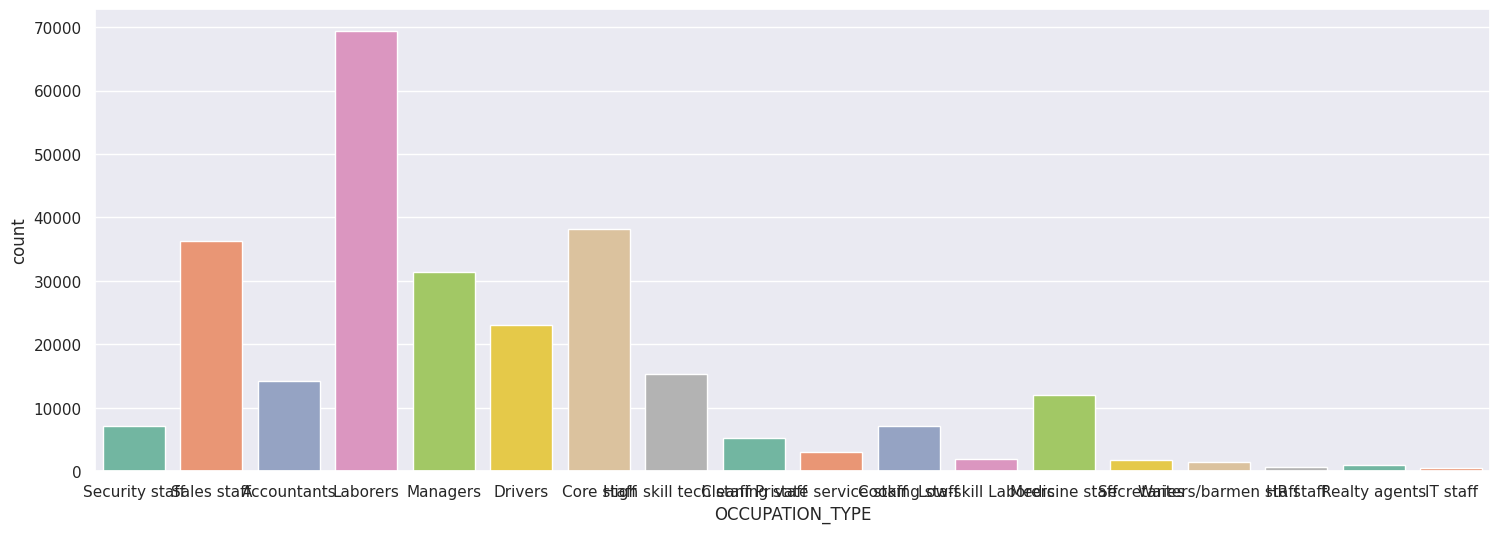

In [8]:
print('Number of people working status: ')
print(app['OCCUPATION_TYPE'].value_counts())
sns.set(rc={'figure.figsize':(18,6)})
sns.countplot(x='OCCUPATION_TYPE',data=app,palette ='Set2')

<Axes: >

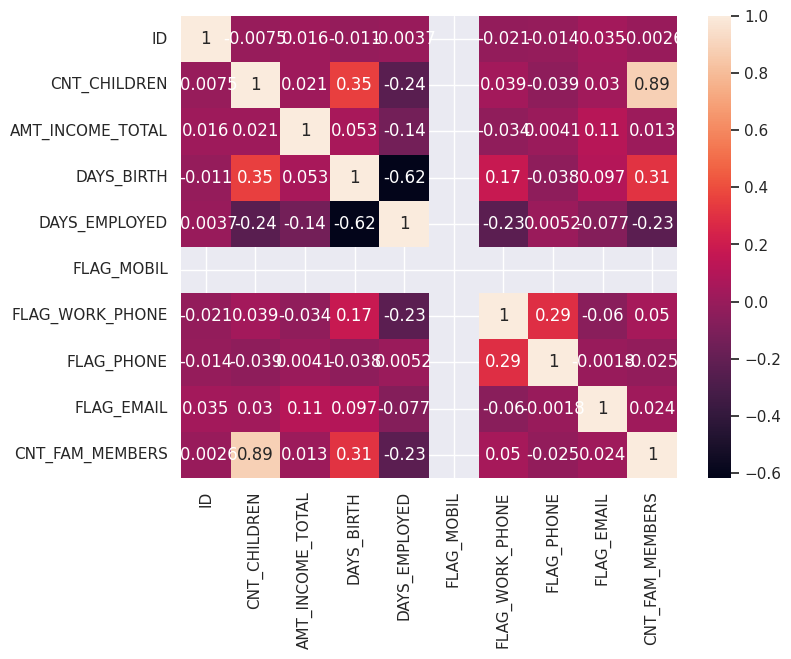

In [10]:
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(app.select_dtypes(include=np.number).corr(),annot=True)

In [11]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,3.892230e+05,389223.000000,3.892230e+05,389222.000000,389222.000000,389222.0,389222.000000,389222.000000,389222.000000,389222.000000
mean,5.914437e+06,0.427138,1.876813e+05,-16008.611127,60545.178795,1.0,0.208341,0.290826,0.106993,2.195153
std,4.863333e+05,0.725359,1.102327e+05,4181.747763,138762.638112,0.0,0.406123,0.454144,0.309105,0.897604
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.536566e+06,0.000000,1.215000e+05,-19490.000000,-3112.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,5.975333e+06,0.000000,1.620000e+05,-15643.000000,-1475.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.277388e+06,1.000000,2.250000e+05,-12531.250000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,6.841875e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000
